The rates vs redshift plots for the common envelope $\alpha=2$.

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

## Read in Data for $\alpha=2.00$

In [2]:
## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS_CE2 = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS_CE2  = h5.File(pathToH5_NSNS_CE2, "r")

DCOs_NSNS_CE2 = Data_NSNS_CE2['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS_CE2 = Data_NSNS_CE2['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [3]:
# gathering information to mask the data even more
# merges in a Hubble Time
# times (these should be in Myr)
lifetimes_all_CE2 = DCOs_NSNS_CE2['Time'][()]
lifetimes_DCO_CE2 = lifetimes_all_CE2[DCO_mask_NSNS_CE2]

col_times_all_CE2 = DCOs_NSNS_CE2['Coalescence_Time'][()]
col_times_DCO_CE2 = col_times_all_CE2[DCO_mask_NSNS_CE2]

delay_times_DCO_CE2 = lifetimes_DCO_CE2 + col_times_DCO_CE2
condition_mergers_CE2 = delay_times_DCO_CE2 < 14100 # Myr

# gathering the rates data
rates_DCO_CE2 = Data_NSNS_CE2['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked_CE2 = rates_DCO_CE2[condition_mergers_CE2]

In [4]:
redshifts_NSNS_CE2 = Data_NSNS_CE2['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

In [5]:
# gathering just the DCO objects that merge within a Hubble Time
stellar_types_all_1_CE2 = DCOs_NSNS_CE2['Stellar_Type(1)'][()]
stellar_types_1_DCO_CE2 = stellar_types_all_1_CE2[DCO_mask_NSNS_CE2]
stellar_types_1_merged_CE2 = stellar_types_1_DCO_CE2[condition_mergers_CE2]

stellar_types_all_2_CE2 = DCOs_NSNS_CE2['Stellar_Type(2)'][()]
stellar_types_2_DCO_CE2 = stellar_types_all_2_CE2[DCO_mask_NSNS_CE2]
stellar_types_2_merged_CE2 = stellar_types_2_DCO_CE2[condition_mergers_CE2]

# bool for just the NSNS systems
NSNS_systems_bool_CE2 = np.logical_and(stellar_types_1_merged_CE2==13, stellar_types_2_merged_CE2==13)

# gathering the mixture weight info
mixture_weights_all_CE2 = DCOs_NSNS_CE2['mixture_weight'][()]
mixtrue_weights_DCO_CE2 = mixture_weights_all_CE2[DCO_mask_NSNS_CE2]
mixture_weights_merged_CE2 = mixtrue_weights_DCO_CE2[condition_mergers_CE2]
mixture_weights_merged_NSNS_CE2 = mixture_weights_merged_CE2[NSNS_systems_bool_CE2]

In [6]:
print("Number of NSNS systems:", np.sum(NSNS_systems_bool_CE2))

Number of NSNS systems: 387425


#### Let's do the same for the WDWD systems

In [7]:
## WDWD optimized run
pathToH5_WDWD_CE2 = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD_CE2  = h5.File(pathToH5_WDWD_CE2, "r")

DCOs_WDWD_CE2 = Data_WDWD_CE2['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD_CE2 = Data_WDWD_CE2['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD_CE2 = Data_WDWD_CE2['BSE_System_Parameters']

In [8]:
# gathering information to mask the data even more
# merges in a Hubble Time
lifetimes_all_WDWD_CE2 = DCOs_WDWD_CE2['Time'][()]
lifetimes_DCO_WDWD_CE2 = lifetimes_all_WDWD_CE2[DCO_mask_WDWD_CE2]

col_times_all_WDWD_CE2 = DCOs_WDWD_CE2['Coalescence_Time'][()]
col_times_DCO_WDWD_CE2 = col_times_all_WDWD_CE2[DCO_mask_WDWD_CE2]

delay_times_DCO_WDWD_CE2 = lifetimes_DCO_WDWD_CE2 + col_times_DCO_WDWD_CE2
condition_mergers_WDopt_CE2 = delay_times_DCO_WDWD_CE2 < 14100

# gathering the rates data
rates_DCO_WDopt_CE2 = Data_WDWD_CE2['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked_WDopt_CE2 = rates_DCO_WDopt_CE2[condition_mergers_WDopt_CE2]

In [9]:
redshifts_WDWD_CE2 = Data_WDWD_CE2['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

In [10]:
stellar_types_all_1_WDopt_CE2 = DCOs_WDWD_CE2['Stellar_Type(1)'][()]
stellar_types_1_DCO_WDopt_CE2 = stellar_types_all_1_WDopt_CE2[DCO_mask_WDWD_CE2]
stellar_types_1_merged_WDopt_CE2 = stellar_types_1_DCO_WDopt_CE2[condition_mergers_WDopt_CE2]

stellar_types_all_2_CE2 = DCOs_WDWD_CE2['Stellar_Type(2)'][()]
stellar_types_2_DCO_CE2 = stellar_types_all_2_CE2[DCO_mask_WDWD_CE2]
stellar_types_2_merged_WDopt_CE2 = stellar_types_2_DCO_CE2[condition_mergers_WDopt_CE2]

# gathering the masses
mass_1_all_CE2 = DCOs_WDWD_CE2['Mass(1)'][()]
mass_1_DCO_CE2 = mass_1_all_CE2[DCO_mask_WDWD_CE2]
mass_1_merged_CE2 = mass_1_DCO_CE2[condition_mergers_WDopt_CE2]

mass_2_all_CE2 = DCOs_WDWD_CE2['Mass(2)'][()]
mass_2_DCO_CE2 = mass_2_all_CE2[DCO_mask_WDWD_CE2]
mass_2_merged_CE2 = mass_2_DCO_CE2[condition_mergers_WDopt_CE2]

# we are going to conditions that M1>M2 (not considering mass ratio reversal cases)
M1_CE2 = np.maximum(mass_1_merged_CE2, mass_2_merged_CE2)
M2_CE2 = np.minimum(mass_1_merged_CE2, mass_2_merged_CE2)

# gathering the mixture weight info
mixture_weights_all_WDopt_CE2 = DCOs_WDWD_CE2['mixture_weight'][()]
mixtrue_weights_dco_WDopt_CE2 = mixture_weights_all_WDopt_CE2[DCO_mask_WDWD_CE2]
mixtrue_weights_merged_WDopt_CE2 = mixtrue_weights_dco_WDopt_CE2[condition_mergers_WDopt_CE2]

In [11]:
# let's find the bools for each of our progenitor systems

# WDWD bool with at least one COWD + COWD/HeWD
HeWD_bool_WDWD,COWD_bool_WDWD_CE2,ONeWD_bool_WDWD,HeCOWD_bool_WDWD_CE2,HeONeWD_bool_WDWD,COHeWD_bool_WDWD_CE2,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt_CE2, stellar_types_2_merged_WDopt_CE2)
carbon_oxygen_bool_WDWD_merged_WDopt_CE2 = np.logical_or(COHeWD_bool_WDWD_CE2, np.logical_or(COWD_bool_WDWD_CE2, HeCOWD_bool_WDWD_CE2))

# violent merger - unequal mass + COWD+COWD
mass_unequal_conditon_CE2 = mass_1_merged_CE2 >= 1.0
violent_merger_unequal_bool_CE2 = mass_unequal_conditon_CE2*COWD_bool_WDWD_CE2

# violent merger - equal mass (q_cr = 0.9) + COWD+COWD
mass_min_criteria_CE2 = np.logical_and(mass_1_merged_CE2>=0.8, mass_2_merged_CE2>=0.8)
critical_mass_ratio_bool_CE2 = np.logical_and(M2_CE2/M1_CE2 >= 0.9, mass_min_criteria_CE2)
violent_merger_equal_bool_CE2 = critical_mass_ratio_bool_CE2*COWD_bool_WDWD_CE2

# D6 HVS
SN_Ia_HVS_CE2,two_star_SNIA,Champagne_Supernova = useful_fncs.check_if_SNIA(mass_1_merged_CE2, mass_2_merged_CE2)

# D6 - two explosion
mass_D6_condition_CE2 = mass_1_merged_CE2 < 1.0
d6_two_explosion_CE2 = mass_D6_condition_CE2*carbon_oxygen_bool_WDWD_merged_WDopt_CE2

In [12]:
print("Number of COWD + He/COWD systems:", np.sum(carbon_oxygen_bool_WDWD_merged_WDopt_CE2))
print("Number of Violent Merger - Unequal systems:", np.sum(violent_merger_unequal_bool_CE2))
print("Number of Violent Merger - Equal systems:", np.sum(violent_merger_equal_bool_CE2))
print("Number of SNe Ia HVS systems:", np.sum(SN_Ia_HVS_CE2))
print("Number of D^6 Quadrupole Detonation systems:", np.sum(d6_two_explosion_CE2))

Number of COWD + He/COWD systems: 2501843
Number of Violent Merger - Unequal systems: 29356
Number of Violent Merger - Equal systems: 1599
Number of SNe Ia HVS systems: 32926
Number of D^6 Quadrupole Detonation systems: 2470266


### Let's compute the merger rate

In [11]:
NSNS_rate_CE2 = np.sum(rates_DCO_masked_CE2[NSNS_systems_bool_CE2], axis=0)

In [12]:
cowd_rate_CE2 = np.sum(rates_DCO_masked_WDopt_CE2[carbon_oxygen_bool_WDWD_merged_WDopt_CE2], axis=0)

In [13]:
violent_merger_unequal_rate_CE2 = np.sum(rates_DCO_masked_WDopt_CE2[violent_merger_unequal_bool_CE2], axis=0)

In [14]:
violent_merger_equal_rate_CE2 = np.sum(rates_DCO_masked_WDopt_CE2[violent_merger_equal_bool_CE2], axis=0)

In [15]:
HVS_rate_CE2 = np.sum(rates_DCO_masked_WDopt_CE2[SN_Ia_HVS_CE2], axis=0)

In [16]:
D6_two_explosion_rate_CE2 = np.sum(rates_DCO_masked_WDopt_CE2[d6_two_explosion_CE2], axis=0)

In [17]:
tot_subpop_CE2 = violent_merger_unequal_rate_CE2 + violent_merger_equal_rate_CE2 + HVS_rate_CE2 + D6_two_explosion_rate_CE2

Let's bootstrap these rates!

In [18]:
# let's now do boostrapping for each run

NSNS_rate_2D_CE2 = rates_DCO_masked_CE2[NSNS_systems_bool_CE2] # NSNS optimized
percentiles_CE2 = useful_fncs.bootstrapping_intervals(NSNS_rate_2D_CE2, 50, redshifts_NSNS_CE2)

Bootstrapping :[############################################################] 50/50


In [19]:
WDWD_rate_2D_CE2 = rates_DCO_masked_WDopt_CE2[carbon_oxygen_bool_WDWD_merged_WDopt_CE2] # WDWD optimized
percentiles_WDWD_CE2 = useful_fncs.bootstrapping_intervals(WDWD_rate_2D_CE2, 50, redshifts_WDWD_CE2)

Bootstrapping :[############################################################] 50/50


### Plotting!

In [20]:
h_little = 0.6766

redshifts_briel = [
    0, 0.01, 0.03, (0.025+0.050)/2, 0.073, (0.05+0.15)/2, (0.075+0.125)/2, 0.11, 0.11, 0.13, 
    0.15, (0.125+0.175)/2, 0.16, (0.175+0.225)/2, 0.2, 0.25, (0.15+0.35)/2, (0.225+0.275)/2, 
    0.26, 0.3, (0.275+0.325)/2, 0.35, 0.35, 0.42, 0.44, 0.45, 0.45, (0.35+0.55)/2, 0.46, 0.47, 
    0.47, 0.55, 0.55, 0.55, 0.62, 0.65, (0.55+0.75)/2, 0.65, 0.74, 0.75, 0.75, 0.75, 0.8, 0.83, 0.85, 
    0.85, 0.94, 0.95, 0.95, 1.05, 1.1, 1.14, 1.21, 1.23, 1.25, 1.59, 1.61, 1.69, 1.75, 2.25
]

rates_briel = [
    0.77, 0.82, 0.82, 0.81, 0.71, 1.60, 0.76, 1.08, 0.72, 0.58, 0.93, 0.90, 0.41, 1.01, 0.58,
    1.05, 1.14, 1.06, 0.82, 0.99, 1.27, 0.99, 1.05, 1.34, 0.76, 0.90, 1.05, 1.52, 1.40, 1.22, 
    2.33, 0.93, 1.40, 1.52, 3.76, 1.40, 2.01, 1.43, 2.30, 1.49, 1.98, 1.69, 2.45, 3.79, 2.27, 
    1.66, 1.31, 2.22, 2.24, 2.30, 2.16, 2.06, 3.85, 2.45, 1.87, 1.31, 1.22, 2.97, 2.10, 1.43
]

# converting the rates to the correct units
rates_briel = np.array(rates_briel)
converted_rates_briel = (rates_briel*(10**5))*(h_little**3)

## uncertainties
lower_limits = [
    -0.10, -0.26, -0.32, -0.24, -0.08, -0.85, -0.13, -0.29, -0.20, -0.18, -0.67, -0.10, -0.26, -0.09, 
    -0.23, -0.76, -0.35, -0.08, -0.20, -0.44, -0.10, -0.55, -0.17, -0.93, -0.39, -0.44, -0.17, -0.38, 
    -0.50, -0.17, -0.79, -0.41, -0.17, -0.26, -1.66, -0.15, -0.52, -0.50, -1.20, -0.55, -0.61, -0.17, 
    -0.54, -0.79, -0.64, -0.15, -0.55, -0.73, -0.23, -0.82, -0.35, -0.53, -0.85, -0.82, -0.64, -0.64, 
    -0.67, -1.08, -0.87, -1.11
]

lower_limits = np.array(lower_limits)
converted_lower_limits = (lower_limits*(10**5)*(h_little**3))

upper_limits = [
    0.10, 0.26, 0.32, 0.33, 0.08, 1.46, 0.15, 0.29, 0.08, 0.20, 0.67, 0.11, 0.26, 0.09, 0.23,
    1.75, 0.38, 0.09, 0.20, 0.47, 0.11, 0.55, 0.17, 1.22, 0.67, 0.44, 0.17, 0.32, 0.50, 0.17, 
    1.08, 0.41, 0.17, 0.29, 2.57, 0.15, 0.55, 0.50, 0.96, 0.79, 0.61, 0.17, 0.67, 0.96, 0.64, 
    0.15, 0.64, 0.73, 0.23, 0.82, 0.35, 0.70, 1.05, 0.73, 0.90, 0.99, 1.14, 1.57, 1.31, 2.77
]

upper_limits = np.array(upper_limits)
converted_upper_limits = (upper_limits*(10**5)*(h_little**3))

# multiplied the lower errors by -1 so make them positive to avoid the plt.errorbar error 
y_error = [-1*(converted_lower_limits), converted_upper_limits]


Text(0.5, 1.0, 'Rates vs Redshift: $\\alpha_{\\mathrm{CE}}=2.00$')

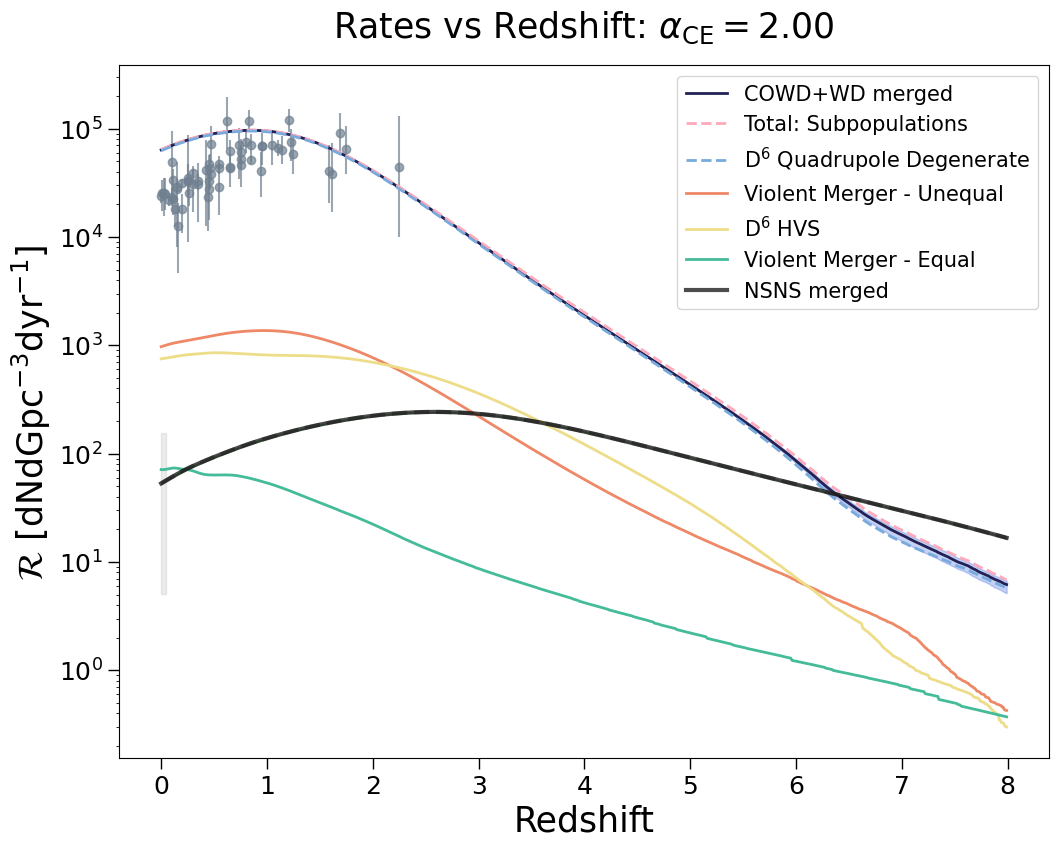

In [23]:
# let's make the plot with just the WDWD progenitor systems

# plotting formation efficencies

fig, ax = plt.subplots(figsize = (12, 9))
cset = tc.dark
cset_l = tc.light

# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax.errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

# COWD
ax.fill_between(redshifts_WDWD_CE2, percentiles_WDWD_CE2[0], percentiles_WDWD_CE2[2], alpha = 0.3, color = 'royalblue')
ax.plot(redshifts_WDWD_CE2, percentiles_WDWD_CE2[1],linewidth=1,color='mediumpurple', ls="--", alpha=0.7)#,label='WDWD rate bootstrapped median')
ax.plot(redshifts_WDWD_CE2, cowd_rate_CE2, linewidth=2,color=cset.dark_blue,label='COWD+WD merged')

# total
ax.plot(redshifts_WDWD_CE2, tot_subpop_CE2, linewidth=2,color=cset_l.pink, ls="--",label='Total: Subpopulations')

# D^6 two explosion 
ax.plot(redshifts_WDWD_CE2, D6_two_explosion_rate_CE2, linewidth=2,color=cset_l.light_blue, ls="--",label='$\mathrm{D^6}$ Quadrupole Degenerate')

# violent merger - unequal 
ax.plot(redshifts_WDWD_CE2, violent_merger_unequal_rate_CE2, linewidth=2,color=cset_l.orange,label='Violent Merger - Unequal')

# HVS
ax.plot(redshifts_WDWD_CE2, HVS_rate_CE2, linewidth=2,color=cset_l.light_yellow,label='$\mathrm{D^6}$ HVS')

# violent merger - equal
ax.plot(redshifts_WDWD_CE2, violent_merger_equal_rate_CE2, linewidth=2,color=cset_l.mint,label='Violent Merger - Equal')

# NSNS
ax.fill_between(redshifts_NSNS_CE2, percentiles_CE2[0], percentiles_CE2[2], alpha = 0.3, color = 'forestgreen')
ax.plot(redshifts_NSNS_CE2, percentiles_CE2[1],linewidth=3,color='grey', ls="--", alpha=0.7)#,label='NSNS rate bootstrapped median')
ax.plot(redshifts_NSNS_CE2, NSNS_rate_CE2,linewidth=3, color='black',alpha=0.7,label='NSNS merged')

## LVK BNS rate (update at z=0 - https://arxiv.org/abs/2605.27226)
plt.fill_between([0,0.05], 
                5.1,
                154.7, 
                alpha=0.15, 
                color="grey")#,label=r'LVK BNS Rate $\mathrm{z=0.2}$')

# ax.set_ylim(np.log(1),np.log(10**6))
ax.set_yscale('log')
ax.set_ylabel(r"$\mathcal{R}$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=25)
ax.set_xlabel(r"Redshift",fontsize=25)
ax.tick_params(axis='x', length=8, width=1, labelsize=18)
ax.tick_params(axis='y', length=8, width=1, labelsize=18)
ax.legend(fontsize=15)
ax.set_title(r"Rates vs Redshift: $\alpha_{\mathrm{CE}}=2.00$", fontsize=25, pad=20)

## save figure:
# plt.savefig("../figures/rates_redshift_CE2.png",bbox_inches='tight',pad_inches=0.1)

### Close the data file

In [13]:
Data_NSNS_CE2.close()
Data_WDWD_CE2.close()